# Week 2 — Linear Models for Regression and Classification

**Syllabus topics:** Maximum likelihood estimation: least squares · robust linear regression · ridge regression · Bayesian linear regression. Linear models for classification: discriminant function, probabilistic generative and discriminative models, Laplace approximation, Bayesian logistic regression, kernel functions, kernels in GLMs, the kernel trick, SVMs.

Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Practice 1 — Implement linear regression to perform prediction (maximum likelihood = least squares)

Predict tomorrow's highest temperature from today's weather. With Gaussian noise, maximum likelihood is least squares, and it has a closed-form answer: the normal equation w = (XᵀX)⁻¹Xᵀy.

same weights as scikit-learn: True
error on 2015:  'tomorrow = today' 2.91 °C  |  linear regression 2.68 °C   (R² = 0.87)
  weight of intercept     +4.93
  weight of precipitation -0.04
  weight of temp_max      +0.66
  weight of temp_min      +0.11
  weight of wind          -0.06
  weight of month_sin     -1.17
  weight of month_cos     -1.98


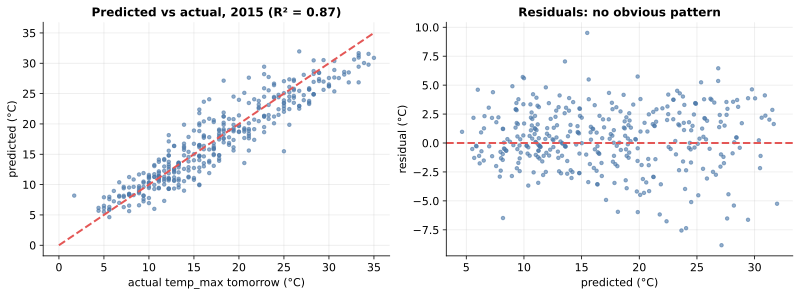

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from weather import load, split, FEATURES

train, test = split(load())                                       # train on 2012-2014, test on 2015
X_tr = np.c_[np.ones(len(train)), train[FEATURES]]                 # a column of ones is the intercept
X_te = np.c_[np.ones(len(test)), test[FEATURES]]
y_tr, y_te = train.temp_tomorrow.values, test.temp_tomorrow.values

w = np.linalg.solve(X_tr.T @ X_tr, X_tr.T @ y_tr)                  # the normal equation
pred = X_te @ w
rmse = lambda y, p: np.sqrt(np.mean((y - p) ** 2))
r2 = 1 - ((y_te - pred) ** 2).sum() / ((y_te - y_te.mean()) ** 2).sum()

print("same weights as scikit-learn:", np.allclose(pred, LinearRegression().fit(train[FEATURES], y_tr).predict(test[FEATURES])))
print(f"error on 2015:  'tomorrow = today' {rmse(y_te, test.temp_max):.2f} °C  |  linear regression {rmse(y_te, pred):.2f} °C   (R² = {r2:.2f})")
for name, wi in zip(["intercept"] + FEATURES, w):
    print(f"  weight of {name:<13} {wi:+.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y_te, pred, s=12, alpha=.6); ax[0].plot([0, 35], [0, 35], "--", color="#e45756")
ax[0].set_xlabel("actual temp_max tomorrow (°C)"); ax[0].set_ylabel("predicted (°C)"); ax[0].set_title(f"Predicted vs actual, 2015 (R² = {r2:.2f})")
ax[1].scatter(pred, y_te - pred, s=12, alpha=.6); ax[1].axhline(0, ls="--", color="#e45756")
ax[1].set_xlabel("predicted (°C)"); ax[1].set_ylabel("residual (°C)"); ax[1].set_title("Residuals: no obvious pattern")
plt.show()

## Theory — Robust linear regression

A few wrong measurements can drag a least-squares line away. Robust regression (here Huber's loss, fitted by re-weighted least squares) down-weights the points that do not fit. We corrupt 25 hot days on purpose to see it.

slope with the 25 bad days:  least squares 1.081 | robust (ours) 1.178 | robust (scikit-learn) 1.171
slope on the clean data:     1.218   <- the robust fit stays close to this


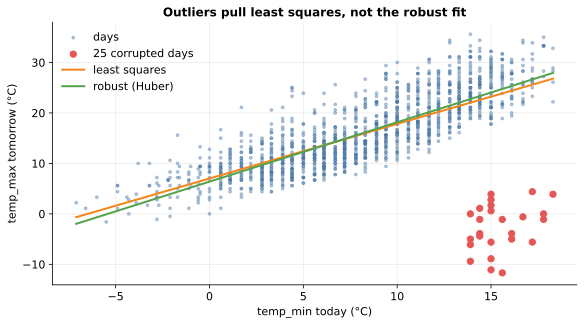

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor
from weather import load

d = load().dropna()
x, y = d.temp_min.values, d.temp_tomorrow.values.copy()
bad = np.random.default_rng(0).choice(np.where(x > np.quantile(x, .8))[0], 25, replace=False)   # 25 of the hottest days
y[bad] -= 30                                                         # recorded wrongly, e.g. a broken thermometer
A = np.c_[np.ones(len(x)), x]

w_ols = np.linalg.lstsq(A, y, rcond=None)[0]
w = w_ols.copy()
for _ in range(50):                                                  # iteratively re-weighted least squares
    r = y - A @ w
    scale = np.median(np.abs(r)) / 0.6745                            # robust estimate of the noise size
    weight = np.minimum(1, 1.345 * scale / np.maximum(np.abs(r), 1e-9))   # Huber weights: big residuals count less
    w = np.linalg.solve(A.T @ (A * weight[:, None]), A.T @ (weight * y))

sk = HuberRegressor().fit(x[:, None], y)
clean = np.polyfit(x[np.setdiff1d(np.arange(len(y)), bad)], y[np.setdiff1d(np.arange(len(y)), bad)], 1)
print(f"slope with the 25 bad days:  least squares {w_ols[1]:.3f} | robust (ours) {w[1]:.3f} | robust (scikit-learn) {sk.coef_[0]:.3f}")
print(f"slope on the clean data:     {clean[0]:.3f}   <- the robust fit stays close to this")

grid = np.array([x.min(), x.max()])
plt.figure(figsize=(8, 4.4))
plt.scatter(x, y, s=8, alpha=.4, label="days"); plt.scatter(x[bad], y[bad], s=40, color="#e45756", label="25 corrupted days")
plt.plot(grid, w_ols[0] + w_ols[1] * grid, label="least squares", color="#f58518")
plt.plot(grid, w[0] + w[1] * grid, label="robust (Huber)", color="#54a24b")
plt.xlabel("temp_min today (°C)"); plt.ylabel("temp_max tomorrow (°C)"); plt.title("Outliers pull least squares, not the robust fit"); plt.legend(); plt.show()

## Theory — Ridge regression

Ridge adds a penalty α·Σw² that shrinks the weights. We watch the weights shrink as α grows, and choose α on 2014 (a validation year), never on the test year.

best alpha on the validation year 2014: 8.38
test RMSE 2015: ridge 2.679 °C


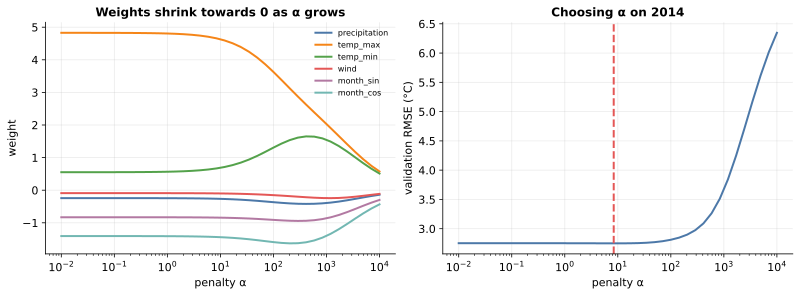

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from weather import load, split, FEATURES

train, test = split(load())
mu, sd = train[FEATURES].mean(), train[FEATURES].std()
Z = lambda df: ((df[FEATURES] - mu) / sd).values                   # same scale for every input
alphas = np.logspace(-2, 4, 40)
paths = np.array([Ridge(alpha=a).fit(Z(train), train.temp_tomorrow).coef_ for a in alphas])

fit_part, val_part = train[train.date < "2014-01-01"], train[train.date >= "2014-01-01"]
val = [np.sqrt(np.mean((val_part.temp_tomorrow - Ridge(alpha=a).fit(Z(fit_part), fit_part.temp_tomorrow).predict(Z(val_part))) ** 2)) for a in alphas]
best = alphas[int(np.argmin(val))]
final = Ridge(alpha=best).fit(Z(train), train.temp_tomorrow)
print(f"best alpha on the validation year 2014: {best:.2f}")
print(f"test RMSE 2015: ridge {np.sqrt(np.mean((test.temp_tomorrow - final.predict(Z(test))) ** 2)):.3f} °C")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for coef, name in zip(paths.T, FEATURES): ax[0].plot(alphas, coef, label=name)
ax[0].set_xscale("log"); ax[0].set_xlabel("penalty α"); ax[0].set_ylabel("weight"); ax[0].set_title("Weights shrink towards 0 as α grows"); ax[0].legend(fontsize=8)
ax[1].plot(alphas, val); ax[1].axvline(best, ls="--", color="#e45756"); ax[1].set_xscale("log")
ax[1].set_xlabel("penalty α"); ax[1].set_ylabel("validation RMSE (°C)"); ax[1].set_title("Choosing α on 2014")
plt.show()

## Theory — Bayesian linear regression

Instead of one set of weights, keep a distribution over them. The posterior is Gaussian, so every prediction comes with an uncertainty band.

RMSE 2.70 °C | the 95% band contains 95% of the 2015 days (ideal: 95%)


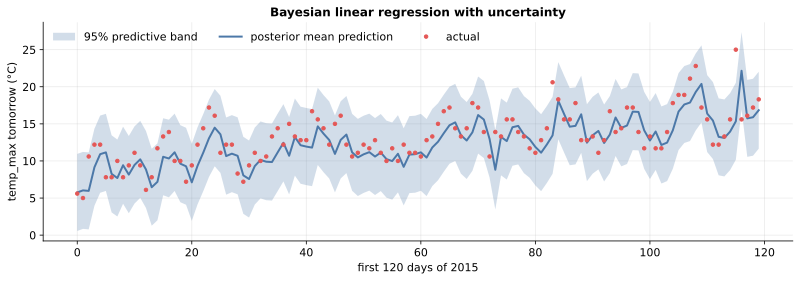

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from weather import load, split, FEATURES

train, test = split(load())
mu, sd = train[FEATURES].mean(), train[FEATURES].std()
add_one = lambda df: np.c_[np.ones(len(df)), ((df[FEATURES] - mu) / sd).values]
X, Xt, y, yt = add_one(train), add_one(test), train.temp_tomorrow.values, test.temp_tomorrow.values

alpha = 1.0                                                            # prior precision: weights are expected to be small
w_ls = np.linalg.lstsq(X, y, rcond=None)[0]
beta = 1 / np.var(y - X @ w_ls)                                        # noise precision, measured on the training data
S = np.linalg.inv(alpha * np.eye(X.shape[1]) + beta * X.T @ X)         # posterior covariance of the weights
m = beta * S @ X.T @ y                                                 # posterior mean of the weights
mean = Xt @ m
sd_pred = np.sqrt(1 / beta + np.einsum("ij,jk,ik->i", Xt, S, Xt))      # noise + uncertainty about the weights
inside = np.abs(yt - mean) < 1.96 * sd_pred
print(f"RMSE {np.sqrt(np.mean((yt - mean) ** 2)):.2f} °C | the 95% band contains {inside.mean():.0%} of the 2015 days (ideal: 95%)")

days = slice(0, 120)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.fill_between(range(120), (mean - 1.96 * sd_pred)[days], (mean + 1.96 * sd_pred)[days], alpha=.25, label="95% predictive band")
ax.plot(mean[days], label="posterior mean prediction"); ax.plot(yt[days], "o", ms=3.5, color="#e45756", label="actual")
ax.set_xlabel("first 120 days of 2015"); ax.set_ylabel("temp_max tomorrow (°C)"); ax.set_title("Bayesian linear regression with uncertainty"); ax.legend(ncol=3); plt.show()

## Theory — Discriminant functions, generative and discriminative models for classification

A generative model describes how each class produces data (here: Gaussians with a shared covariance) and applies Bayes' rule. A discriminative model (logistic regression) models P(class | x) directly. For equal covariances both give a linear discriminant.

generative model (Gaussian classes):  accuracy 0.720   (same as scikit-learn's LDA: 1.00 agreement)
discriminative model (logistic):      accuracy 0.728
baselines on 2015:  'always no rain' 0.604  |  'tomorrow = today' 0.703


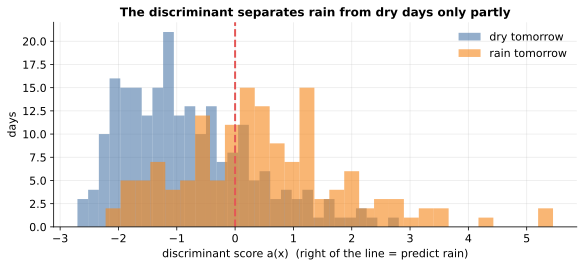

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from weather import load, split, FEATURES

train, test = split(load())
X, y = train[FEATURES].values, train.rain_tomorrow.values.astype(int)
Xt, yt = test[FEATURES].values, test.rain_tomorrow.values.astype(int)

prior = np.array([(y == k).mean() for k in (0, 1)])                    # P(class)
mean = np.array([X[y == k].mean(0) for k in (0, 1)])                    # class means
cov = sum(np.cov(X[y == k], rowvar=False) * ((y == k).sum() - 1) for k in (0, 1)) / (len(y) - 2)   # shared covariance
w = np.linalg.solve(cov, mean[1] - mean[0])                             # discriminant a(x) = wᵀx + w0
w0 = -0.5 * (mean[1] + mean[0]) @ w + np.log(prior[1] / prior[0])
score = Xt @ w + w0                                                     # a(x) > 0  ->  predict rain
acc = lambda pred: (pred == yt).mean()
print(f"generative model (Gaussian classes):  accuracy {acc(score > 0):.3f}   (same as scikit-learn's LDA: {np.mean((score > 0) == LinearDiscriminantAnalysis().fit(X, y).predict(Xt)):.2f} agreement)")
print(f"discriminative model (logistic):      accuracy {acc(LogisticRegression(max_iter=2000).fit(X, y).predict(Xt)):.3f}")
print(f"baselines on 2015:  'always no rain' {acc(0):.3f}  |  'tomorrow = today' {acc(test.rain.values):.3f}")

plt.figure(figsize=(8, 3.6))
plt.hist(score[yt == 0], bins=30, alpha=.6, label="dry tomorrow"); plt.hist(score[yt == 1], bins=30, alpha=.6, label="rain tomorrow")
plt.axvline(0, color="#e45756", ls="--"); plt.xlabel("discriminant score a(x)  (right of the line = predict rain)"); plt.ylabel("days")
plt.title("The discriminant separates rain from dry days only partly"); plt.legend(); plt.show()

## Practice 2 — Implement Bayesian logistic regression (Laplace approximation) for classification

The posterior of logistic regression has no closed form, so the Laplace approximation fits a Gaussian at its peak. Newton's method finds the peak; the curvature there gives the width.

Bayesian logistic regression   accuracy 0.731 | log-loss 0.558
ordinary logistic regression   accuracy 0.731 | log-loss 0.558


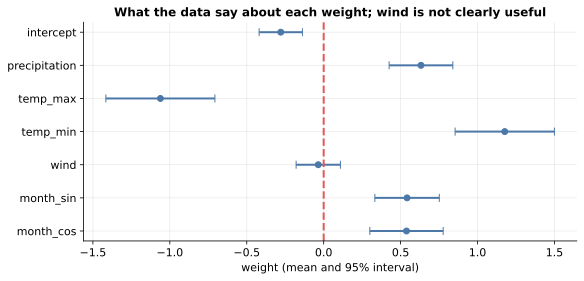

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss
from weather import load, split, FEATURES

train, test = split(load())
sc = StandardScaler().fit(train[FEATURES])
A = np.c_[np.ones(len(train)), sc.transform(train[FEATURES])]
At = np.c_[np.ones(len(test)), sc.transform(test[FEATURES])]
y, yt = train.rain_tomorrow.values, test.rain_tomorrow.values
sigmoid = lambda z: 1 / (1 + np.exp(-z))

prior = 1.0                                                             # prior precision of the weights
w = np.zeros(A.shape[1])
for _ in range(25):                                                     # Newton's method for the most probable weights
    p = sigmoid(A @ w)
    grad = A.T @ (p - y) + prior * w
    hess = A.T @ (A * (p * (1 - p))[:, None]) + prior * np.eye(len(w))
    w -= np.linalg.solve(hess, grad)
cov = np.linalg.inv(hess)                                               # Gaussian approximation of the posterior

mu, var = At @ w, np.einsum("ij,jk,ik->i", At, cov, At)
p_bayes = sigmoid(mu / np.sqrt(1 + np.pi * var / 8))                    # predictive probability, softened when unsure
p_plain = LogisticRegression(max_iter=1000).fit(A[:, 1:], y).predict_proba(At[:, 1:])[:, 1]
for name, p in [("Bayesian logistic regression", p_bayes), ("ordinary logistic regression", p_plain)]:
    print(f"{name:<30} accuracy {np.mean((p > .5) == yt):.3f} | log-loss {log_loss(yt, p):.3f}")

names, sd = ["intercept"] + FEATURES, np.sqrt(np.diag(cov))
plt.figure(figsize=(8, 3.8))
plt.errorbar(w, range(len(w)), xerr=1.96 * sd, fmt="o", capsize=4)
plt.yticks(range(len(w)), names); plt.axvline(0, color="#e45756", ls="--"); plt.gca().invert_yaxis()
plt.xlabel("weight (mean and 95% interval)"); plt.title("What the data say about each weight; wind is not clearly useful"); plt.show()

## Practice 2 — Implement SVM for classification: kernel functions, kernels in GLMs and the kernel trick

A kernel k(x, x') measures similarity and lets a linear method draw curved boundaries (the kernel trick). We build the RBF kernel by hand, use it inside logistic regression (a GLM) and inside an SVM, and draw the boundaries.

our kernel matches scikit-learn's: True
logistic regression                        accuracy 0.712
kernel logistic (GLM on kernel features)   accuracy 0.706


linear SVM                                 accuracy 0.717
RBF SVM                                    accuracy 0.703


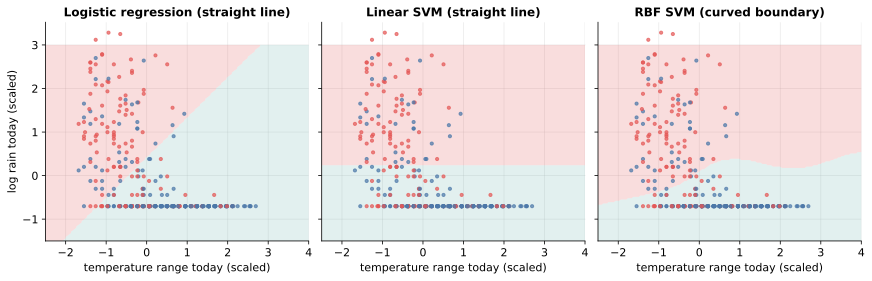

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import rbf_kernel
from weather import load, split

train, test = split(load())
two = lambda df: np.c_[df.temp_max - df.temp_min, np.log1p(df.precipitation)]       # daily temperature range and (log) rain today
mu, sd = two(train).mean(0), two(train).std(0)
X, Xt = (two(train) - mu) / sd, (two(test) - mu) / sd
y, yt = train.rain_tomorrow.values, test.rain_tomorrow.values

gamma = 0.5
def kernel(a, b):                                                       # k(x, x') = exp(-gamma * |x - x'|²)
    return np.exp(-gamma * ((a[:, None] - b[None]) ** 2).sum(-1))
print("our kernel matches scikit-learn's:", np.allclose(kernel(X[:50], X[:50]), rbf_kernel(X[:50], X[:50], gamma=gamma)))

models = {
    "logistic regression": LogisticRegression(),
    "kernel logistic (GLM on kernel features)": None,
    "linear SVM": SVC(kernel="linear"),
    "RBF SVM": SVC(kernel="rbf", gamma=gamma),
}
K, Kt = kernel(X, X), kernel(Xt, X)                                     # similarity of every day to every training day
klog = LogisticRegression(C=1.0, max_iter=2000).fit(K, y)
for name, m in models.items():
    if m is None: print(f"{name:<42} accuracy {klog.score(Kt, yt):.3f}"); continue
    print(f"{name:<42} accuracy {m.fit(X, y).score(Xt, yt):.3f}")

xx, yy = np.meshgrid(np.linspace(-2.5, 4, 150), np.linspace(-1.5, 3, 150)); G = np.c_[xx.ravel(), yy.ravel()]
fig, ax = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
panels = [("Logistic regression (straight line)", models["logistic regression"].predict(G)),
          ("Linear SVM (straight line)", models["linear SVM"].predict(G)),
          ("RBF SVM (curved boundary)", models["RBF SVM"].predict(G))]
for a, (title, z) in zip(ax, panels):
    a.contourf(xx, yy, z.reshape(xx.shape), alpha=.2, levels=[-.5, .5, 1.5], colors=["#72b7b2", "#e45756"])
    a.scatter(Xt[:, 0], Xt[:, 1], c=np.where(yt == 1, "#e45756", "#4c78a8"), s=10, alpha=.7); a.set_title(title); a.set_xlabel("temperature range today (scaled)")
ax[0].set_ylabel("log rain today (scaled)"); plt.show()